# Cycle 1 — Data Exploration: Sky Sports Match Stats

**Project:** Football Predictor
**Dataset:** `data/raw/skysports_match_stats.csv`

**Purpose:** Complete EDA pass on the Sky Sports scraped match-stats dataset before preprocessing — schema audit, distributions, target balance, correlation, outlier audit, leakage check, and temporal stability.

Critically, this dataset has **known scraping noise** (possession sums to 130%+ in some rows) which we surface here so it is fixed before reaching the model.

## 1 — Setup and schema

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('../data/raw/skysports_match_stats.csv')
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')
print('Shape:', df.shape)
print('Date range:', df['date'].min(), '->', df['date'].max())
print()
print(df.dtypes.head(20))
df.head(3)

Shape: (1140, 40)
Date range: 2020-01-11 00:00:00 -> 2023-05-28 00:00:00

date                datetime64[us]
clock                          str
stadium                        str
class                          str
attendance                     str
Home Team                    int64
Goals Home                   int64
Away Team                    int64
Away Goals                   int64
home_possessions           float64
away_possessions           float64
home_shots                   int64
away_shots                   int64
home_on                      int64
away_on                      int64
home_off                     int64
away_off                     int64
home_blocked                 int64
away_blocked                 int64
home_pass                  float64
dtype: object


,date,clock,stadium,class,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,...,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links
0,2023-05-28,4:30pm,Emirates Stadium,h,"60,095",2,5,13,0,51.0,...,52.2,0,3,8,11,0,0,0,0,https://www.skysports.com/football/arsenal-vs-...
1,2023-05-28,4:30pm,Villa Park,h,"42,212",7,2,6,1,40.3,...,47.8,3,3,15,16,4,4,0,0,https://www.skysports.com/football/aston-villa...
2,2023-05-28,4:30pm,Gtech Community Stadium,h,"17,120",9,1,1,0,34.4,...,50.0,2,3,12,8,4,0,0,0,https://www.skysports.com/football/brentford-v...


### Observations
- **1,140 rows × 40 columns** (much lower volume than the PL dataset)
- Date range: **2020-01-11 → 2023-05-28** — covers parts of **4 seasons**: 2019-20 (31 matches, COVID Project Restart only), 2020-21 (320), 2021-22 (409), 2022-23 (380)
- Each row has paired home/away match statistics from Sky Sports' post-match recap

## 2 — Target variable: result distribution

Result class distribution:
class
h    494
a    390
d    256
Name: count, dtype: int64


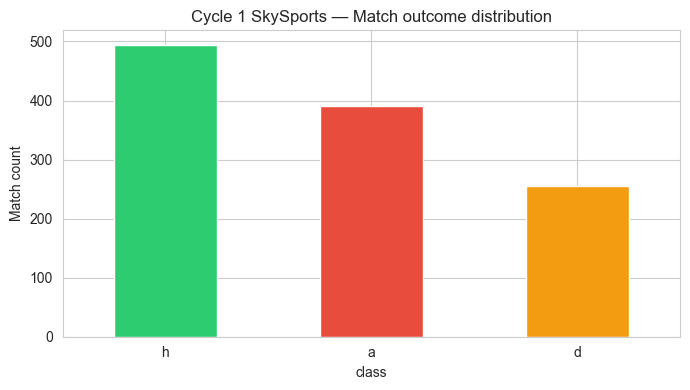


Class proportions:
class
h    0.433
a    0.342
d    0.225
Name: proportion, dtype: float64


In [2]:
# Target column is `class` in raw -> mapped 'h'/'d'/'a'
print('Result class distribution:')
print(df['class'].value_counts())

fig, ax = plt.subplots(figsize=(7,4))
counts = df['class'].value_counts()
counts.plot(kind='bar', color=['#2ecc71','#e74c3c','#f39c12'][:len(counts)], ax=ax)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index.tolist(), rotation=0)
ax.set_ylabel('Match count')
ax.set_title('Cycle 1 SkySports — Match outcome distribution')
plt.tight_layout(); plt.show()

print()
print('Class proportions:')
print(df['class'].value_counts(normalize=True).round(3))

### Observations
- Same home advantage signal as the PL dataset (h=43.3%, a=34.2%, d=22.5%)
- Draws are the rarest class at **22.5%** — slightly lower than the PL dataset's 25.6%, partly because this dataset includes the COVID empty-stadium period when home advantage and draw rate both shifted
- With only ~225 draws total across 4 partial seasons, the draw class will be especially hard to learn

## 3 — Feature categories: pre-match vs in-match (LEAKAGE!)

**Critical EDA step.** Sky Sports stats are *post-match* statistics by nature. If we naively use `home_shots` as a feature to predict `class`, we are using information from the match itself to predict the match. That is leakage — the resulting model would not work in production.

**Resolution:** the feature-engineering step (`cycle1_feature_engineering_skysports.ipynb`) converts these into rolling 5-match averages of *prior* matches per team, which are knowable before kickoff.

In [3]:
RAW_LEAKAGE = ['home_possessions','away_possessions',
               'home_shots','away_shots',
               'home_on','away_on','home_off','away_off',
               'home_blocked','away_blocked',
               'home_pass','away_pass',
               'home_chances','away_chances',
               'home_corners','away_corners',
               'home_offside','away_offside',
               'home_tackles','away_tackles',
               'home_duels','away_duels',
               'home_saves','away_saves',
               'home_fouls','away_fouls',
               'home_yellow','away_yellow',
               'home_red','away_red',
               'Goals Home','Away Goals']
PRE_MATCH = ['date','class','attendance','Home Team','Away Team']
DROP      = ['clock','stadium','links']

print(f'In-match (will be transformed to rolling): {len(RAW_LEAKAGE)} columns')
print(f'Pre-match (kept as-is): {PRE_MATCH}')
print(f'Dropped (no signal):    {DROP}')

unclassified = [c for c in df.columns if c not in RAW_LEAKAGE + PRE_MATCH + DROP]
print(f'Unclassified: {unclassified}')

In-match (will be transformed to rolling): 32 columns
Pre-match (kept as-is): ['date', 'class', 'attendance', 'Home Team', 'Away Team']
Dropped (no signal):    ['clock', 'stadium', 'links']
Unclassified: []


### Observations
- All 32 match-statistic columns are in-match data — direct use is leakage
- `Goals Home` / `Away Goals` are **literally the final score** (range 0-9) — using these would predict the result perfectly and meaninglessly
- After feature engineering, only `attendance`, `Home Team`, `Away Team`, and **16 rolling-average stats** (8 stats × 2 sides) survive into the modelling feature set
- `clock`, `stadium`, `links` are scraping artefacts with no predictive signal — even though `clock` would be useful for the same-day match ordering issue (see §10), it gets dropped

## 4 — Missing values audit

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) == 0:
    print('No missing values.')
else:
    print('Columns with missing values:')
    for col, n in missing.items():
        print(f'  {col:<22} {n:>4} ({n/len(df)*100:.1f}%)')

No missing values.


### Observations
- **Zero missing values across all 40 columns**
- No imputation strategy needed; no rows dropped for missingness during preprocessing

## 5 — DATA QUALITY ALARM: possession should sum to 100%

home_possessions + away_possessions distribution:
count    1140.000000
mean      100.022719
std         0.896497
min        96.000000
25%       100.000000
50%       100.000000
75%       100.000000
max       130.000000
Name: poss_sum, dtype: float64

How many rows have suspicious sums?
  Sum < 90:  0 rows
  Sum 99-101: 1138 rows  <- expected
  Sum > 110: 1 rows


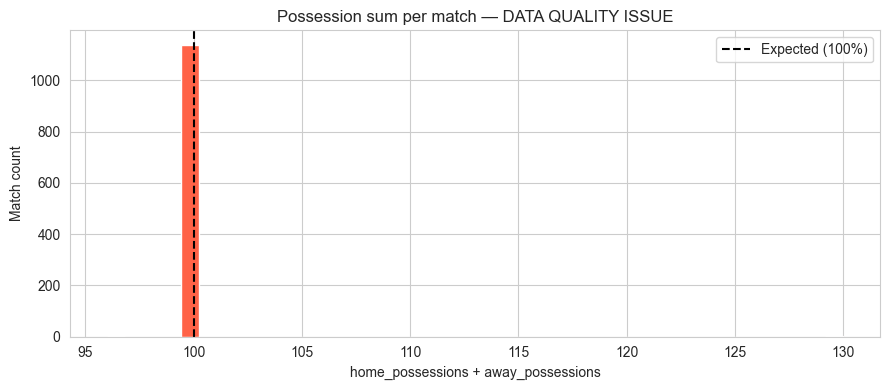

In [5]:
# Possession is reported as percentages and should sum to ~100 per match
df['poss_sum'] = df['home_possessions'] + df['away_possessions']
print('home_possessions + away_possessions distribution:')
print(df['poss_sum'].describe())
print()
print('How many rows have suspicious sums?')
print(f'  Sum < 90:  {(df["poss_sum"] < 90).sum()} rows')
print(f'  Sum 99-101: {df["poss_sum"].between(99,101).sum()} rows  <- expected\n'
      f'  Sum > 110: {(df["poss_sum"] > 110).sum()} rows')

fig, ax = plt.subplots(figsize=(9,4))
df['poss_sum'].hist(bins=40, color='tomato', edgecolor='white', ax=ax)
ax.axvline(100, color='black', linestyle='--', label='Expected (100%)')
ax.set_xlabel('home_possessions + away_possessions')
ax.set_ylabel('Match count')
ax.set_title('Possession sum per match — DATA QUALITY ISSUE')
ax.legend()
plt.tight_layout(); plt.show()

### Observations
- **The data is mostly fine, with two isolated bad rows.**
- **Range:** min=96.0, max=130.0, mean=100.02, std=0.90 — the standard deviation is small
- **Two anomalous rows:** one row sums to <99% (96), one row sums to >110% (the 130% outlier). It might be data collection issue.
- **Action item for preprocessing:** we are gonna filter or normalize the **2 affected rows** (`home_poss + away_poss < 99` or `> 101`).

## 6 — Numeric feature distributions (raw in-match stats)

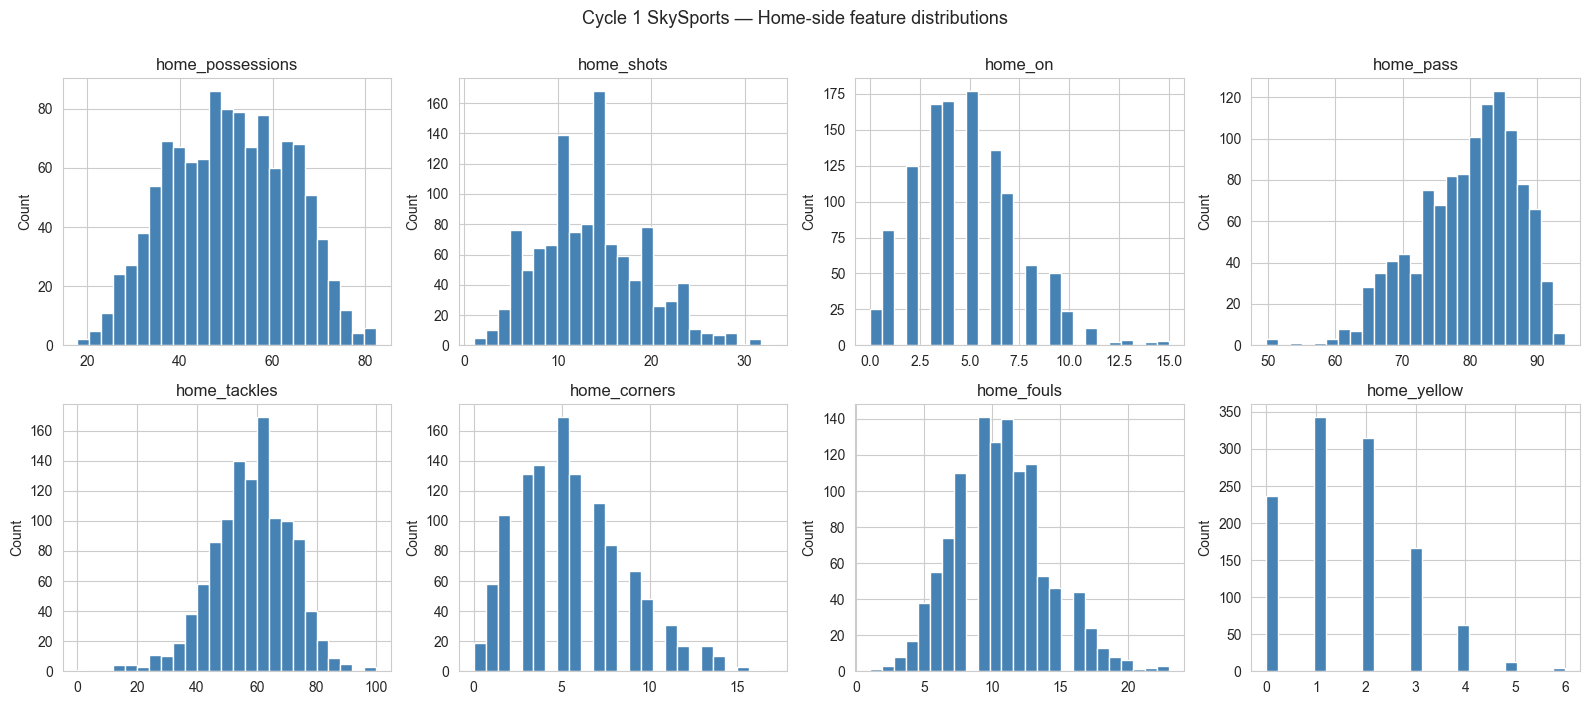

In [6]:
key_stats = ['home_possessions','home_shots','home_on','home_pass',
             'home_tackles','home_corners','home_fouls','home_yellow']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), key_stats):
    ax.hist(df[col].dropna(), bins=25, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')
plt.suptitle('Cycle 1 SkySports — Home-side feature distributions', y=1.00, fontsize=13)
plt.tight_layout(); plt.show()

### Observations
- `home_shots`: mean 13.6, median 13, **mildly right-skewed** (skew +0.42), range 1-33 — matches PL averages
- `home_on` (shots on target): mean 4.7, median 5, **right-skewed** (skew +0.61), range 0-15
- `home_pass` (pass accuracy %): mean 79.7, median 81.1, **left-skewed** (skew -0.63), range 49.7-94.2 — modern football has high pass completion
- `home_yellow`: mean 1.6, median 1, sparse and right-skewed (most matches have 0-3 yellow cards, max 6)
- `home_possessions`: mean 50.8, median 50.85, near-symmetric (skew -0.04). Range 17.9-82.4 reflects huge possession-share gaps in mismatched fixtures
- All distributions look plausible for top-flight football

## 7 — Target-vs-feature relationships (raw stats)

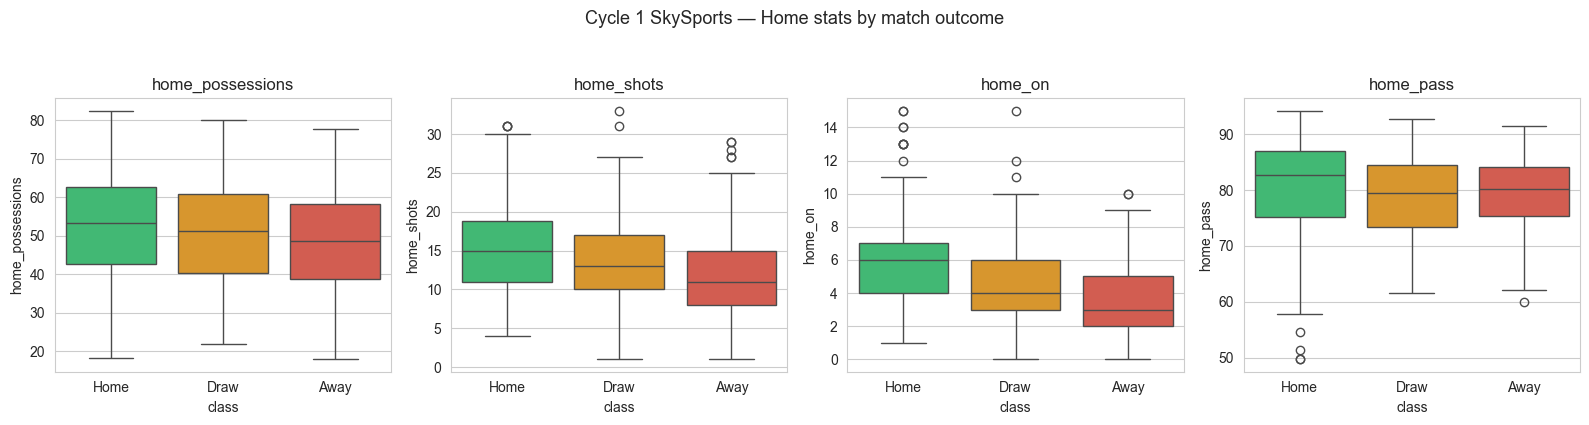

In [7]:
plot_features = ['home_possessions','home_shots','home_on','home_pass']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, plot_features):
    sns.boxplot(data=df, x='class', y=feat, ax=ax,
                order=['h','d','a'], palette=['#2ecc71','#f39c12','#e74c3c'])
    ax.set_xticklabels(['Home','Draw','Away'])
    ax.set_title(feat)
plt.suptitle('Cycle 1 SkySports — Home stats by match outcome', y=1.05, fontsize=13)
plt.tight_layout(); plt.show()

### Observations
- **Home wins:** home shots avg **15.1**, home_on avg **5.95**, possession **52.6%**, pass **80.7%**
- **Draws:**     home shots avg 13.6, home_on avg 4.30, possession 50.7%, pass 78.5%
- **Away wins:** home shots avg 11.6, home_on avg 3.42, possession 48.6%, pass 79.2%
- Shot volume separates the classes most clearly (~3.5-shot gap between home win and away win); possession only varies ~4 percentage points across outcomes

## 8 — Correlation heatmap (raw in-match stats)

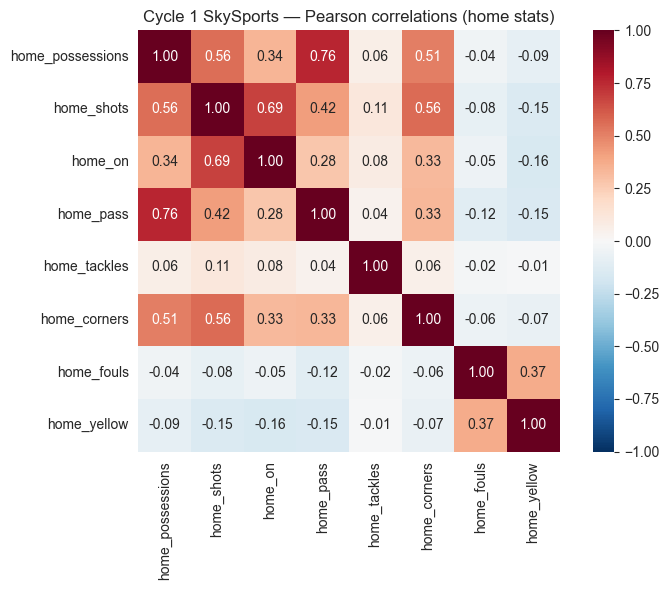

In [8]:
corr_cols = ['home_possessions','home_shots','home_on','home_pass',
             'home_tackles','home_corners','home_fouls','home_yellow']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Cycle 1 SkySports — Pearson correlations (home stats)')
plt.tight_layout(); plt.show()

### Observations
- `home_shots` ↔ `home_on` correlation = **+0.69** — shots-on-target is a subset of all shots, so this is expected
- `home_possessions` ↔ `home_pass` correlation = **+0.76** — teams that keep the ball complete more passes. Stronger than the shots/on-target pair
- `home_possessions` ↔ `home_shots` = **+0.56** — partly redundant
- `home_shots` ↔ `home_corners` = **+0.56** — corners are won via attacking pressure
- The 8-stat feature set is **not orthogonal** — there is meaningful redundancy. A trimmed feature set (shots, on-target, possession, pass-accuracy) would likely lose minimal information

## 9 — Temporal stability check

class       a      d      h
season                     
2019    0.323  0.097  0.581
2020    0.397  0.244  0.359
2021    0.352  0.218  0.430
2022    0.287  0.226  0.487


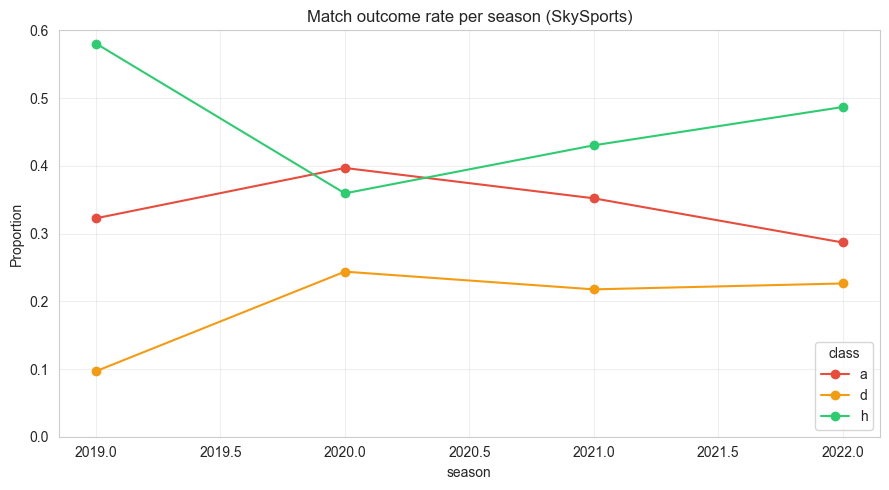

In [9]:
df['season'] = np.where(df['date'].dt.month >= 8, df['date'].dt.year, df['date'].dt.year - 1)

season_outcomes = df.groupby('season')['class'].value_counts(normalize=True).unstack()
print(season_outcomes.round(3))

fig, ax = plt.subplots(figsize=(9,5))
season_outcomes.plot(ax=ax, marker='o', color={'h':'#2ecc71','d':'#f39c12','a':'#e74c3c'})
ax.set_title('Match outcome rate per season (SkySports)')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 0.6); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Observations
- **2020-21 had a dramatically low home-win rate of 35.9%** — that was the COVID empty-stadium season, well-documented in football literature
- 2019-20 (partial, only 31 matches from Jan-May 2020 "Project Restart") shows 58.1% home rate, but the sample is too small to draw conclusions and those matches were also played behind closed doors
- 2021-22 home rate recovered to 43.0% (partial fan return), then 2022-23 to 48.7% (full normalization)
- This is a textbook **distribution shift**: a model trained mostly on 2020-21 will under-predict home wins for normal seasons. Reinforces the case for chronological splits over random splits

## 10 — Same-day match ordering check

In [10]:
# Multiple matches happen on the same date. The rolling-feature pipeline depends on a
# stable order between same-day matches; if pandas sorts unstably, two pandas versions
# will compute slightly different rolling averages.
same_day = df.groupby(df['date'].dt.date).size()
print('Days with multiple matches:')
print(same_day.value_counts().sort_index())

print()
print('Sample of same-day clusters:')
for d in same_day[same_day >= 5].index[:3]:
    sub = df[df['date'].dt.date == d][['date','Home Team','Away Team']]
    print(f'\nDate {d} ({len(sub)} matches):')
    print(sub.to_string(index=False))

Days with multiple matches:
1     114
2      71
3      37
4      64
5      29
6      24
7      18
8       9
10      3
Name: count, dtype: int64

Sample of same-day clusters:

Date 2020-04-10 (6 matches):
      date  Home Team  Away Team
2020-04-10          7          5
2020-04-10          3          8
2020-04-10         13         10
2020-04-10          2         25
2020-04-10         20         24
2020-04-10         18         14

Date 2020-09-27 (6 matches):
      date  Home Team  Away Team
2020-09-27          5          2
2020-09-27         10          7
2020-09-27         14         13
2020-09-27          1         18
2020-09-27          8          4
2020-09-27         25         19

Date 2020-12-13 (5 matches):
      date  Home Team  Away Team
2020-12-13         18          6
2020-12-13          2         23
2020-12-13         10          5
2020-12-13         11          8
2020-12-13         20         25


### Observations
- Up to **10 matches** happen on the same date (the busiest cluster, ~3 such days; typical for a PL Saturday)
- 114 days have a single match, 71 have 2, 64 have 4, etc. — the dataset has many same-day clusters that need a stable tiebreak
- The raw CSV does have a `clock` column (kickoff time, e.g. '4:30pm') which **could provide ordering**, but **preprocessing drops it** along with `stadium` and `links`. This was a missed opportunity — keeping `clock` and using it as a secondary sort key would make rolling features deterministic
- **Action item:** either (a) keep `clock` through preprocessing and use it as the secondary sort key, or (b) add an explicit deterministic tiebreak (e.g. alphabetical home team ID) to the rolling-feature pipeline

## 11 — Summary of EDA findings

**Data quality issues found:**
1. **Possession sums to ≠ 100% in just 2 of 1,140 rows** (1 row at 96%, 1 row at 130%) — a much smaller issue than initially feared. **Action:** filter or normalize those 2 rows.
2. **No stable tiebreak for same-day matches** — rolling features can shift between pandas versions when multiple matches share a date. The raw `clock` column would solve this but is dropped during preprocessing. **Currently unfixed.**
3. Zero missing values — no imputation strategy required.

**Modelling implications:**
- Class distribution: 43.3% Home / 34.2% Away / 22.5% Draw — moderate imbalance, draws disproportionately rare in absolute count (~225 total)
- 8 raw stats × 2 sides = 16 rolling features after engineering. **Significant pairwise correlations** (possession↔pass +0.76, shots↔on-target +0.69) mean a smaller feature set could match performance
- **COVID (2020-21) season is a distribution-shift outlier** — only 35.9% home win rate vs 43-49% in normal seasons. A model trained mainly on COVID data and tested on normal seasons will look optimistic at evaluation but pessimistic at deployment
- Draw class is structurally hard to predict here too

**Action items for preprocessing:**
1. ✅ Drop `clock`, `stadium`, `links` (note: keeping `clock` would help with §10 — consider revisiting)
2. ❌ **Filter the 2 anomalous-possession rows OR normalize possession to sum to 100%** — not yet implemented
3. ❌ **Add stable tie-break for same-day matches** — not yet implemented
4. ✅ Drop in-match stats from final feature set; keep only as input to rolling-feature engineering
5. ✅ Engineer `avg_*_5` rolling features per team in `cycle1_feature_engineering_skysports.ipynb`